# Spatial Filtering Operations

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import conv

## Convolution (kernel_size = (3,3))

In [43]:
def convolution(img, kernel):
    # First padding the image
    padded_img = np.pad(img, pad_width=1, mode='constant', constant_values=0)

    result = np.zeros(img.shape)
    
    f = padded_img.copy()
    w = kernel.copy()

    responses = list()
    
    # Applying convolution
    for x in range(1, padded_img.shape[0]-1):
        for y in range(1, padded_img.shape[1]-1):
            response = f[x-1][y-1]*w[0][0] + f[x-1][y]*w[0][1] + f[x-1][y+1]*w[0,2] + \
                       f[x][y-1]*w[1][0] + f[x][y]*w[1][1] + f[x][y]*w[1][2] + \
                       f[x+1][y-1]*w[2][0] + f[x+1][y]*w[2][1] + f[x+1][y+1]*w[2][2]
            responses.append(response)

    # Place the response in the resulting image
    c = 0
    for x in range(img.shape[0]):
        for y in range(img.shape[1]):
            result[x][y] = responses[c]
            c += 1

    return result

### Code for displaying two images in a row

In [75]:
def show(img1, img2, cap1, cap2):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap='gray')
    plt.title(cap1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img2, cmap='gray')
    plt.title(cap2)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

### Reading the image

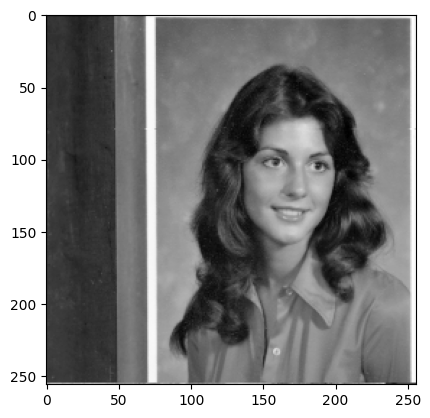

In [26]:
# Read the image
img = cv2.imread('misc/4.1.04.tiff', 0)
# Display the iamge
plt.imshow(img, cmap='gray')

### General convolution

In [44]:
kernel = np.array([[1,2,3],
                   [4,5,6],
                   [7,8,9]])

result = convolution(img, kernel)

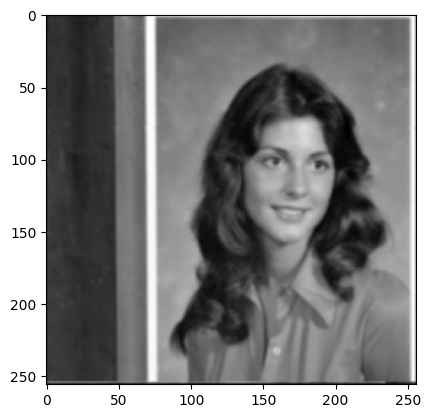

In [45]:
# Show result
plt.imshow(result, cmap='gray')

### Robert's Operator

In [88]:
kernel_x = np.array([[0,0,0],
                     [0,-1,0],
                     [0,0,1]])

kernel_y = np.array([[0,0,0],
                     [0,0,-1],
                     [0,1,0]])

result_x = convolution(img, kernel_x)
result_y = convolution(img, kernel_y)

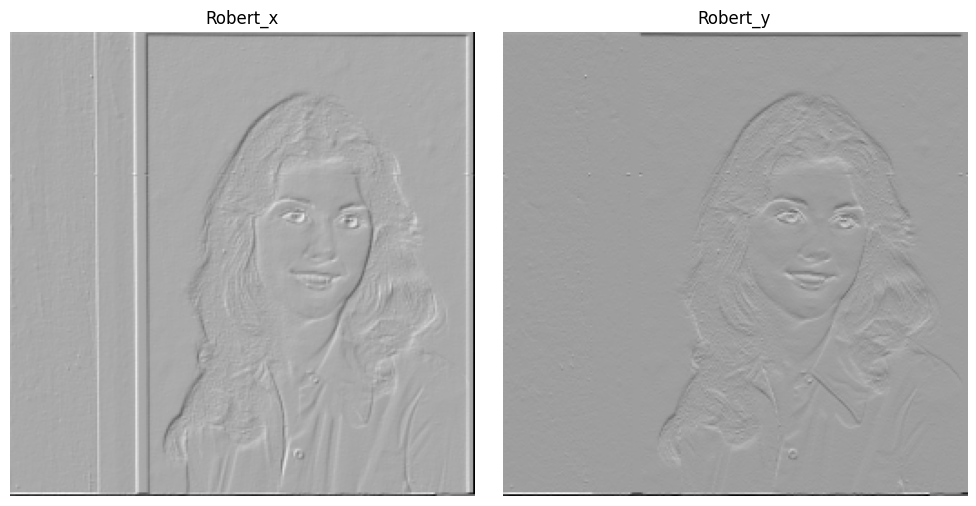

In [90]:
show(result_x, result_y, 'Robert_x', 'Robert_y')

### Sobel Operator

In [46]:
kernel_x = np.array([[-1,-2,-1],
                     [0,0,0],
                     [1,2,1]])

kernel_y = np.array([[-1,0,1],
                     [-2,0,2],
                     [-1,0,1]])

result_x = convolution(img, kernel_x)
result_y = convolution(img, kernel_y)

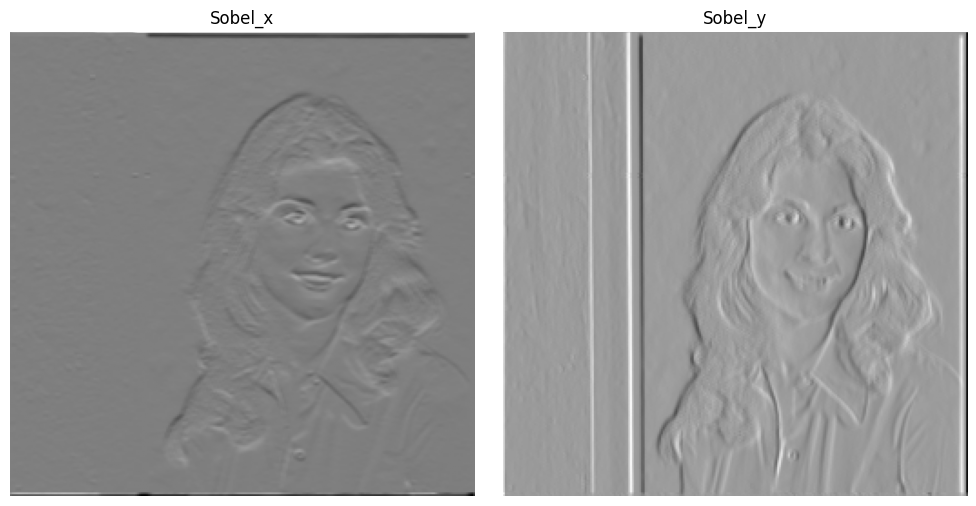

In [76]:
show(result_x, result_y, 'Sobel_x', 'Sobel_y')

### Prewitt Operator

In [61]:
kernel__x = np.array([[-1,-1,-1],
                     [0,0,0],
                     [1,1,1]])

kernel_y = np.array([[-1,0,1],
                     [-1,0,1],
                     [-1,0,1]])

result_x = convolution(img, kernel_x)
result_y = convolution(img, kernel_y)

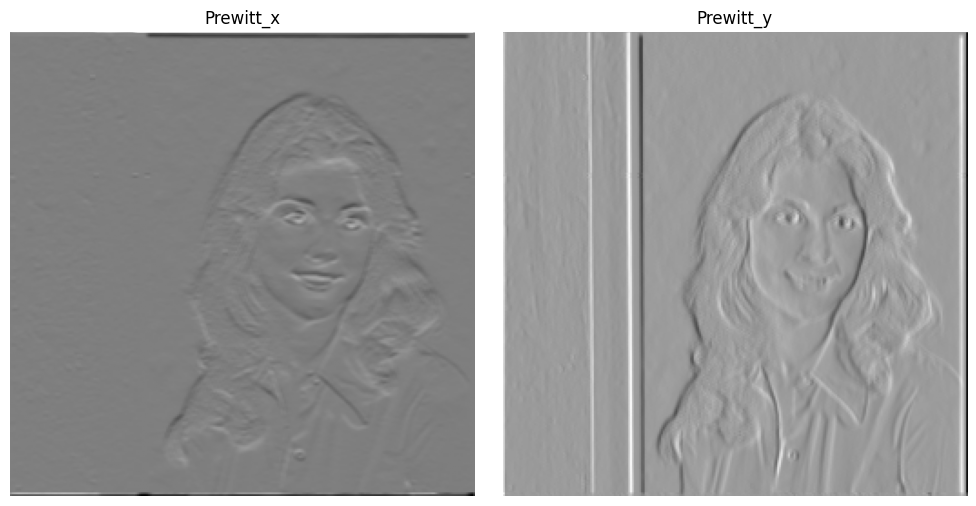

In [77]:
show(result_x, result_y, 'Prewitt_x', 'Prewitt_y')

### Laplacian Operator

In [79]:
laplacian_cn = np.array([[0,1,0],
                     [1,-4,1],
                     [0,1,0]])

laplacian_cp = np.array([[0,-1,0],
                     [-1,4,-1],
                     [0,-1,0]])

result_cn = convolution(img, laplacian_cn)
result_cp = convolution(img, laplacian_cp)

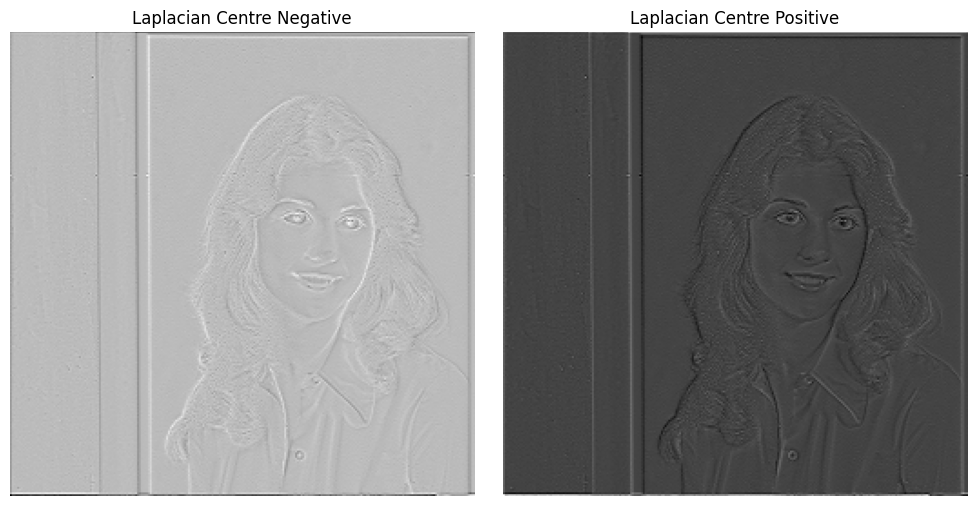

In [80]:
show(result_cn, result_cp, 'Laplacian Centre Negative', 'Laplacian Centre Positive' )

### Laplacian of Gaussian

Smoothed image


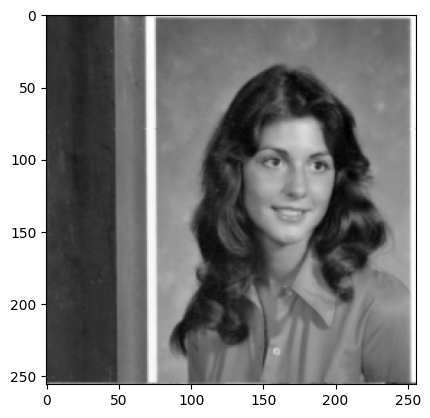

In [85]:
gaussian_img = cv2.GaussianBlur(img, (5, 5), 0.5)
print('Smoothed image')
plt.imshow(gaussian_img, cmap='gray')

In [86]:
result_cn = convolution(gaussian_img, laplacian_cn)
result_cp = convolution(gaussian_img, laplacian_cp)

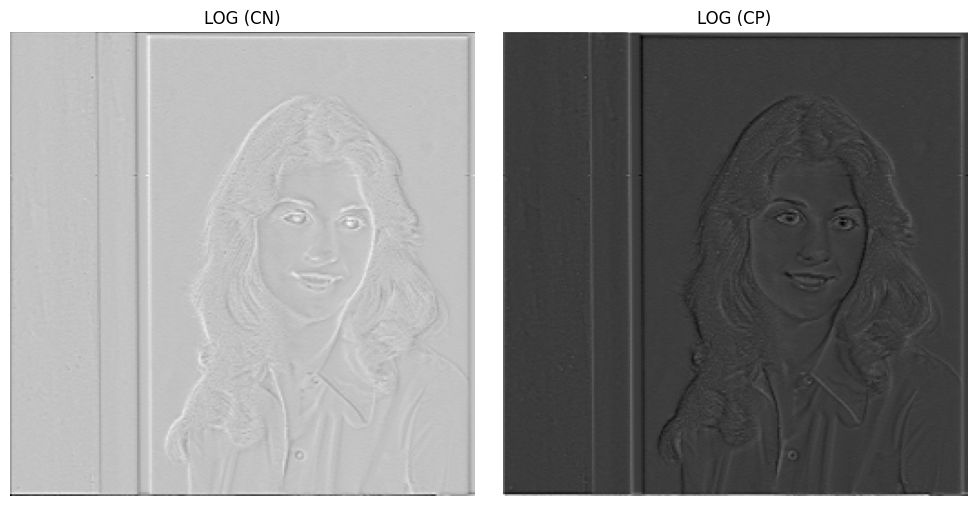

In [87]:
show(result_cn, result_cp, 'LOG (CN)', 'LOG (CP)')